# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/interim/` de los datos de entrenamiento.
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

In [30]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [31]:
# 1. Leer el archivo CSV proveniente de la carpeta data/raw/
df = pd.read_csv("../data/interim/train_set.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (13209, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-118.39,33.88,33.0,2543.0,439.0,1098.0,416.0,5.9683,495500.0,<1H OCEAN
1,-122.44,37.76,50.0,2589.0,569.0,945.0,544.0,5.2519,376600.0,NEAR BAY
2,-118.19,33.82,11.0,872.0,203.0,422.0,221.0,4.6364,156300.0,NEAR OCEAN
3,-118.14,34.16,30.0,2598.0,757.0,2869.0,769.0,2.1377,142300.0,<1H OCEAN
4,-117.31,33.16,17.0,1704.0,263.0,781.0,281.0,5.6605,224400.0,NEAR OCEAN


In [32]:
# 2. Analizar la estructura del dataset: tipos de datos, valores faltantes, estadísticas descriptivas.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 13209 entries, 0 to 13208
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           13209 non-null  float64
 1   latitude            13209 non-null  float64
 2   housing_median_age  13209 non-null  float64
 3   total_rooms         13209 non-null  float64
 4   total_bedrooms      13069 non-null  float64
 5   population          13209 non-null  float64
 6   households          13209 non-null  float64
 7   median_income       13209 non-null  float64
 8   median_house_value  13209 non-null  float64
 9   ocean_proximity     13209 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.0 MB
None


Del análisis de la estructura, se visualizan datos faltantes en total_bedrooms. 
El detalle de las columnas se muestran a continuación:
- longitude → Longitud (coordenada geográfica oeste–este).
- latitude → Latitud (coordenada geográfica norte–sur).
- housing_median_age → Edad mediana de las viviendas del área.
- total_rooms → Total de cuartos en todas las viviendas del área.
- total_bedrooms → Total de dormitorios en todas las viviendas del área.
- population → Número total de personas que viven en el área.
- households → Número total de hogares (grupos de personas que comparten vivienda).
- median_income → Ingreso mediano de los hogares (en decenas de miles de dólares).
- median_house_value → Valor mediano de las viviendas (variable objetivo).
- ocean_proximity → Categoría que indica qué tan cerca está el área del océano.

In [33]:
# estadísticas descriptivas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,13209.000000,13209.000000,13209.000000,13209.000000,13069.000000,13209.000000,13209.000000,13209.000000,13209.000000
mean,-119.577798,35.645993,28.520024,2633.056401,537.010253,1421.772428,498.265577,3.864435,205683.655084
std,1.999027,2.130017,12.589832,2163.461488,418.204417,1086.095522,378.346504,1.887502,115431.298315
min,-124.350000,32.550000,1.000000,6.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.780000,33.930000,18.000000,1451.000000,295.000000,785.000000,279.000000,2.555600,118300.000000
50%,-118.520000,34.270000,28.000000,2125.000000,434.000000,1169.000000,409.000000,3.535300,178100.000000
75%,-118.010000,37.720000,37.000000,3148.000000,642.000000,1721.000000,601.000000,4.751500,263600.000000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100,500001.000000


In [34]:
# verificar los datos de la casa con median_house_value = 14999
df[df["median_house_value"] == 14999]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6098,-122.74,39.71,16.0,255.0,73.0,85.0,38.0,1.6607,14999.0,INLAND
6683,-117.02,36.40,19.0,619.0,239.0,490.0,164.0,2.1000,14999.0,INLAND


In [35]:
# verificar los datos de households = 2
df[df["households"] == 2]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
3534,-116.95,33.86,1.0,6.0,2.0,8.0,2.0,1.625,55000.0,INLAND
5186,-119.54,36.51,36.0,49.0,7.0,28.0,2.0,4.625,162500.0,INLAND


In [36]:
# verificar datos de viviendas con median_house_value = 500001
df[df["median_house_value"] == 500001]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
7,-118.38,34.06,52.0,1311.0,217.0,578.0,205.0,7.6771,500001.0,<1H OCEAN
41,-122.47,37.81,45.0,6927.0,1258.0,4715.0,1165.0,3.4051,500001.0,NEAR BAY
97,-118.44,34.06,9.0,5102.0,1695.0,2609.0,1450.0,3.2545,500001.0,<1H OCEAN
114,-117.90,33.60,25.0,2465.0,585.0,906.0,472.0,3.6538,500001.0,<1H OCEAN
131,-119.61,34.45,33.0,3597.0,519.0,1207.0,479.0,5.3963,500001.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
13086,-118.08,34.13,46.0,1238.0,147.0,377.0,145.0,8.4546,500001.0,INLAND
13101,-118.35,34.07,45.0,3312.0,880.0,1157.0,809.0,3.5719,500001.0,<1H OCEAN
13132,-118.49,34.11,27.0,6603.0,879.0,2336.0,868.0,13.2935,500001.0,<1H OCEAN
13168,-118.49,34.04,31.0,4066.0,951.0,1532.0,868.0,4.8125,500001.0,<1H OCEAN


In [37]:
#completitud
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        140
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [38]:
# porcentaje de valores faltantes
faltantes = df.isnull().sum()
porcentaje_faltantes = (faltantes / len(df)) * 100
print(porcentaje_faltantes)

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.059883
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


In [39]:
#visualizar datos de las filas de las viviendas con datos faltantes
datos_con_faltantes=df[df.isnull().any(axis=1)]
datos_con_faltantes.sample(20)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
3841,-118.55,34.19,18.0,5862.0,NaN,3161.0,1280.0,3.1106,170600.0,<1H OCEAN
5071,-118.17,33.98,41.0,756.0,NaN,873.0,212.0,2.7321,156000.0,<1H OCEAN
79,-121.08,39.22,30.0,2188.0,NaN,1033.0,437.0,2.1419,105200.0,INLAND
11084,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,143100.0,INLAND
7093,-120.37,38.01,30.0,473.0,NaN,242.0,93.0,2.5417,123200.0,INLAND
12833,-121.19,38.71,11.0,4415.0,NaN,1520.0,627.0,3.2321,390800.0,INLAND
11161,-116.93,32.79,19.0,3354.0,NaN,1948.0,682.0,3.0192,142300.0,<1H OCEAN
12126,-122.38,37.73,40.0,543.0,NaN,259.0,89.0,2.2167,193800.0,NEAR BAY
992,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,146500.0,<1H OCEAN
6926,-117.91,33.87,29.0,1121.0,NaN,762.0,276.0,2.5000,143800.0,<1H OCEAN


In [40]:
datos_con_faltantes.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,140.000000,140.000000,140.000000,140.000000,0.0,140.000000,140.000000,140.000000,140.000000
mean,-119.492857,35.532214,28.728571,2536.607143,NaN,1443.442857,514.864286,3.741895,200850.035714
std,2.003593,2.049825,11.985509,1774.117986,NaN,1079.298702,424.215369,1.928026,111881.635216
min,-124.130000,32.660000,4.000000,154.000000,NaN,37.000000,16.000000,0.852700,45800.000000
25%,-121.540000,33.957500,18.000000,1305.750000,NaN,748.000000,252.500000,2.626625,119825.000000
50%,-118.540000,34.250000,29.000000,2058.500000,NaN,1121.000000,403.000000,3.310350,169100.000000
75%,-118.050000,37.527500,37.000000,3430.500000,NaN,1870.250000,639.000000,4.306650,263950.000000
max,-114.590000,40.920000,52.000000,11709.000000,NaN,7604.000000,3589.000000,15.000100,500001.000000


- No existe relación entre datos de las viviendas con total_bedrooms faltantes, por lo que es un mecanismo MCAR.

In [41]:
# precisión, duplicados
duplicados = df.duplicated().sum()
duplicados

np.int64(0)

In [42]:
# búsqueda de tricky duplicates, es decir, duplicados en columnas clave
tricky_duplicates = df[df.duplicated(subset=["longitude", "latitude","population"], keep=False)]
tricky_duplicates.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
465,-119.08,35.34,15.0,1474.0,235.0,768.0,238.0,4.1528,130100.0,INLAND
799,-118.22,33.97,47.0,1058.0,295.0,1097.0,274.0,2.8810,183300.0,<1H OCEAN
3167,-118.17,34.04,43.0,908.0,232.0,1005.0,224.0,1.7500,134000.0,<1H OCEAN
3580,-118.22,33.97,47.0,1147.0,297.0,1097.0,307.0,2.6384,162900.0,<1H OCEAN
6986,-119.08,35.34,16.0,1535.0,238.0,768.0,236.0,5.4449,118500.0,INLAND


In [43]:
# visualizar datos de viviendas con longitude = -117.96, latitude = 33.78, population = 658
df[(df["longitude"] == -117.96) & (df["latitude"] == 33.78) & (df["population"] == 658)]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
7667,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.37,229200.0,<1H OCEAN


In [44]:
# visualizar datos de viviendas con longitude = -119.08, latitude = 35.34, population = 768
df[(df["longitude"] == -119.08) & (df["latitude"] == 35.34) & (df["population"] == 768)]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
465,-119.08,35.34,15.0,1474.0,235.0,768.0,238.0,4.1528,130100.0,INLAND
6986,-119.08,35.34,16.0,1535.0,238.0,768.0,236.0,5.4449,118500.0,INLAND


In [45]:
# búsqueda de tricky duplicates, es decir, duplicados en columnas clave
tricky_duplicates_2 = df[df.duplicated(subset=["longitude", "latitude","population","median_house_value"], keep=False)]
tricky_duplicates_2.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [46]:
# Consistencia (tipos y categorías)
print(df.dtypes)
print()
print(df["ocean_proximity"].value_counts())

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

ocean_proximity
<1H OCEAN     5786
INLAND        4295
NEAR OCEAN    1644
NEAR BAY      1483
ISLAND           1
Name: count, dtype: int64


In [47]:
# outliers
iqr = df["median_house_value"].quantile(0.75) - df["median_house_value"].quantile(0.25)
limite_inferior = df["median_house_value"].quantile(0.25) - 1.5 * iqr
limite_superior = df["median_house_value"].quantile(0.75) + 1.5 * iqr
outliers = df[(df["median_house_value"] < limite_inferior) | (df["median_house_value"] > limite_superior)]
print(f"Cantidad de outliers: {len(outliers)}")

Cantidad de outliers: 675


In [48]:
# Cálculo de outliers mediante el iqr en todas las variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
outliers

longitude               0
latitude                0
housing_median_age      0
total_rooms           834
total_bedrooms        842
population            781
households            793
median_income         421
median_house_value    675
dtype: int64

Text(0.5, 1.0, 'Boxplot de median_house_value')

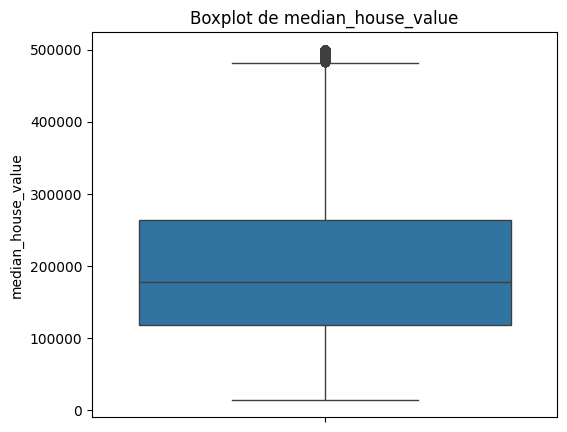

In [49]:
# gráfico de outliers con bigotes hacia arriba y abajo
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["median_house_value"])
plt.title("Boxplot de median_house_value")

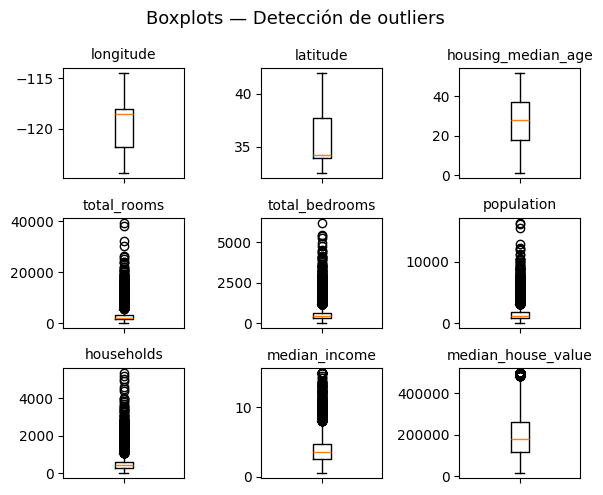

In [50]:
numericas = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(3, 3, figsize=(6, 5))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels([])

plt.suptitle("Boxplots — Detección de outliers", fontsize=13)
plt.tight_layout()
plt.show()

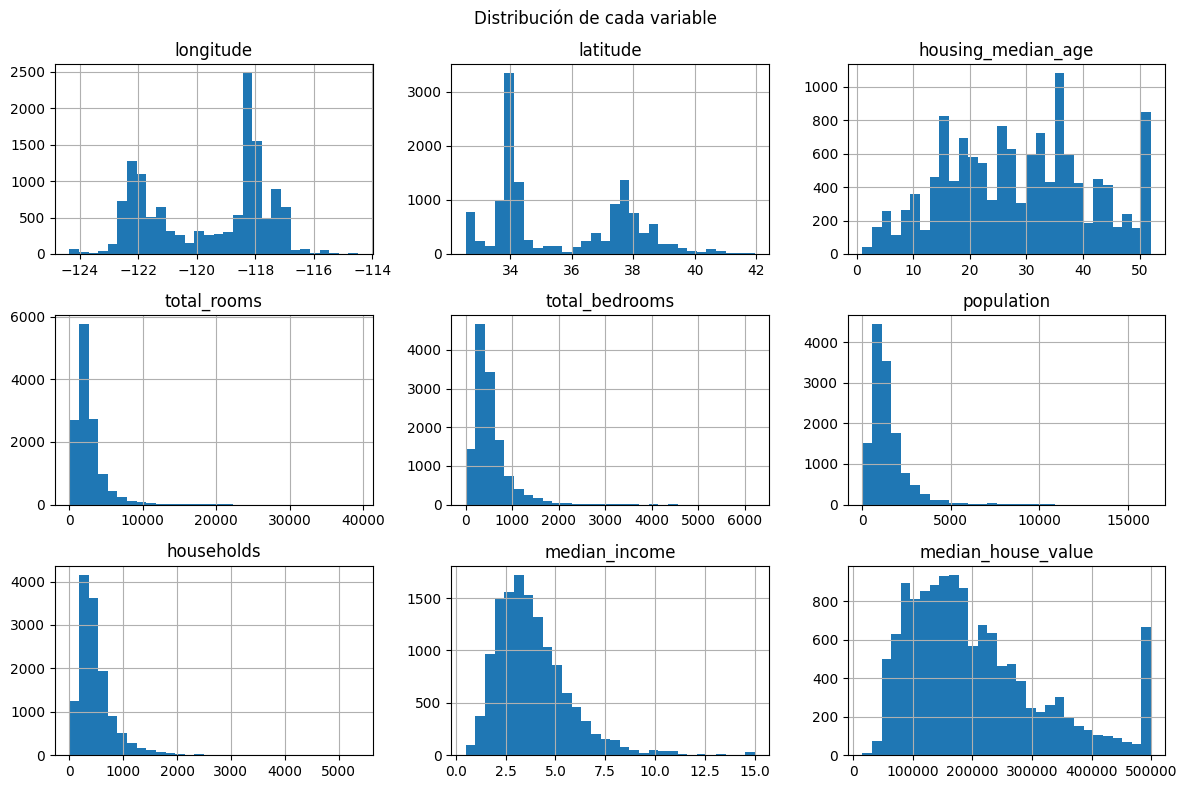

In [51]:
# Un histograma por cada variable numérica
df.hist(figsize=(12, 8), bins=30)

plt.suptitle("Distribución de cada variable")
plt.tight_layout()
plt.show()

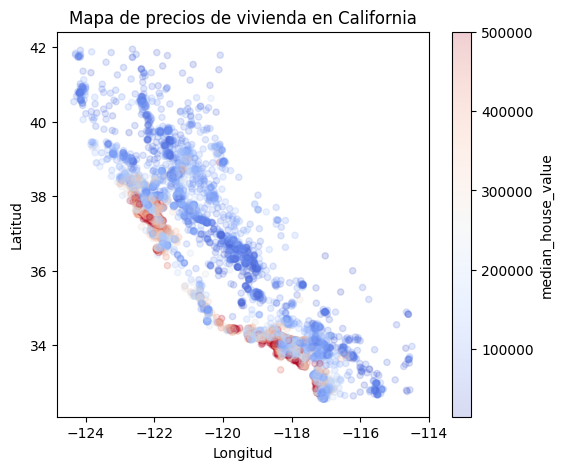

In [52]:
# Usamos longitud y latitud para ubicar cada vivienda en el mapa
# El color representa el precio: rojo = caro, azul = barato
df.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.2,
    c="median_house_value",
    cmap="coolwarm",
    figsize=(6, 5),
    colorbar=True
)

plt.title("Mapa de precios de vivienda en California")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

In [53]:
# .corr() calcula qué tan relacionada está cada variable con las demás
# Usamos numeric_only=True para evitar problemas con variables categóricas
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924152,-0.104536,0.044340,0.070506,0.103866,0.055492,-0.016423,-0.052017
latitude,-0.924152,1.000000,0.008521,-0.038040,-0.068913,-0.116093,-0.073537,-0.079863,-0.139748
housing_median_age,-0.104536,0.008521,1.000000,-0.362126,-0.320618,-0.303976,-0.302594,-0.119211,0.107478
total_rooms,0.044340,-0.038040,-0.362126,1.000000,0.931758,0.861900,0.918056,0.200726,0.140251
total_bedrooms,0.070506,-0.068913,-0.320618,0.931758,1.000000,0.884335,0.978015,-0.002091,0.057537
population,0.103866,-0.116093,-0.303976,0.861900,0.884335,1.000000,0.915302,0.006524,-0.018331
households,0.055492,-0.073537,-0.302594,0.918056,0.978015,0.915302,1.000000,0.017876,0.075054
median_income,-0.016423,-0.079863,-0.119211,0.200726,-0.002091,0.006524,0.017876,1.000000,0.689805
median_house_value,-0.052017,-0.139748,0.107478,0.140251,0.057537,-0.018331,0.075054,0.689805,1.000000


In [54]:
# Correlación en relación a median_house_value
correlaciones = df.corr(numeric_only=True)["median_house_value"]
# Ordenamos de mayor a menor correlación
correlaciones.sort_values(ascending=False)

median_house_value    1.000000
median_income         0.689805
total_rooms           0.140251
housing_median_age    0.107478
households            0.075054
total_bedrooms        0.057537
population           -0.018331
longitude            -0.052017
latitude             -0.139748
Name: median_house_value, dtype: float64

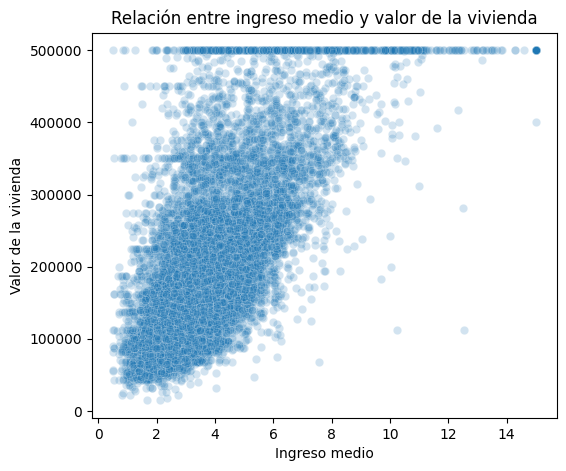

In [55]:
# Gráfico de dispersión entre las variables más correlacionadas y el precio
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["median_income"], y=df["median_house_value"], alpha=0.2)
plt.title("Relación entre ingreso medio y valor de la vivienda")
plt.xlabel("Ingreso medio")
plt.ylabel("Valor de la vivienda")
plt.show()

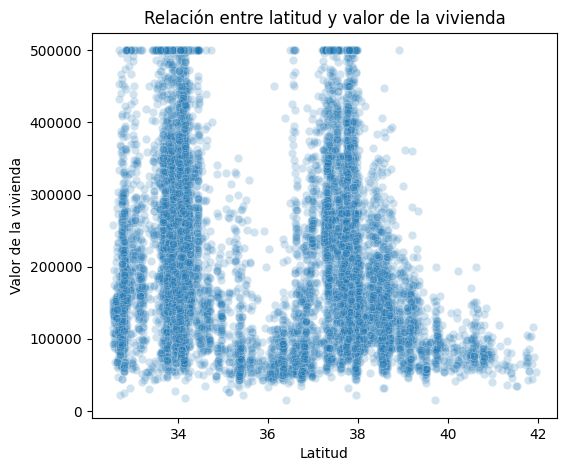

In [56]:
# Gráfico de dispersión entre latitud y el precio
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["latitude"], y=df["median_house_value"], alpha=0.2)
plt.title("Relación entre latitud y valor de la vivienda")
plt.xlabel("Latitud")
plt.ylabel("Valor de la vivienda")
plt.show()

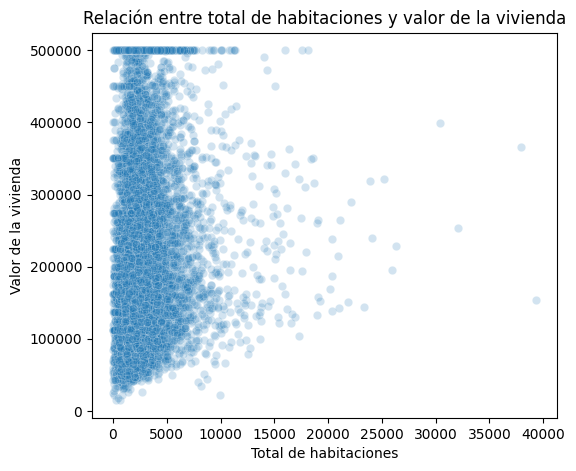

In [57]:
# Gráfico de dispersión entre total_rooms y el precio
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["total_rooms"], y=df["median_house_value"], alpha=0.2)
plt.title("Relación entre total de habitaciones y valor de la vivienda")
plt.xlabel("Total de habitaciones")
plt.ylabel("Valor de la vivienda")
plt.show()

#### Conclusiones de la exploración

##### Consistencia
- Consistencia: No existen problemas de consistencia como datos combinados entre str y float. Sin embargo, existe la columna `ocean_proximity` que es texto con 5 categorías. Esta columna será necesario transformarla a una columna de valores numéricos.
- Sensibilidad: Los valores y rangos de las variables no presentan rangos alterados o incorrectos, se ven coherentes, aunque `median_house_value` tiene un techo en $500,001, pero es un valor acorde a los grupos de categorías evaluadas en el  dataset.
- Completitud: La columna `total_bedrooms` tiene valores ausentes que corresponde al 1.059883 %. La ausencia es totalmente aleatoria e independiente de cualquier variable, por lo que es un mecanismo de ausencia del tipo MCAR. Es necesario llenar los valores faltantes.
- Precisión: No hay filas duplicadas en el dataset ni tricky duplicates.
- Correlación: Existe una fuerte correlación con `median_income`, su valor de correlación corresponde a 0.689805.
- Patrón geográfico: Las casas más cercanas al mar, tienen un precio más alto
- Outliers: Se identifican outliers en variables como total_rooms, total_bedrooms, households, median_income y population.